<a href="https://colab.research.google.com/github/MahuL88/Latihan/blob/main/Menggunakan_Dataset_Tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Menggunakan tf.data.Datasets

In [16]:
import pandas as pd
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import tensorflow_datasets as tfds

In [17]:
mnist = tf.keras.datasets.mnist

In [18]:
# Membagi data menjadi data latih dan uji
(gambar_latih, label_latih), (gambar_testing, label_testing) = mnist.load_data()

5


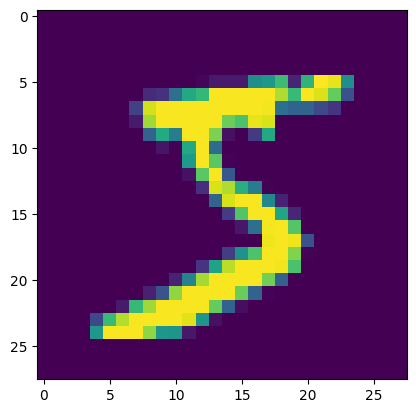

In [19]:
# Tampilkan gambar
np.set_printoptions(linewidth=200)
plt.imshow(gambar_latih[0])
print(label_latih[0])

In [20]:
# Normalisasi
gambar_latih  = gambar_latih / 255.0
gambar_testing = gambar_testing / 255.0

In [21]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),       # di satu dimensikan input yg berukuran 28x28 piksel jadi dimensi sebesar 784 elemen.
    tf.keras.layers.Dense(128, activation=tf.nn.relu),  # Parameter unit merupakan jumlah perceptron pada sebuah layer. dan aktivasi relu
    tf.keras.layers.Dense(10, activation=tf.nn.softmax) # Jumlah unit menyesuaikan dengan jumlah label pada dataset. karna terdapat lebih dari 1 kelas dan aktivasi SoftMax
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [22]:
model.compile(optimizer = tf.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(gambar_latih, label_latih, epochs=5)    # batch_size otomatis 32

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8779 - loss: 0.4331
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9653 - loss: 0.1207
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9757 - loss: 0.0812
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9828 - loss: 0.0581
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9874 - loss: 0.0434


In [23]:
model.evaluate(gambar_testing, label_testing)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9739 - loss: 0.0898


[0.07769499719142914, 0.9768999814987183]

# Model Menggunakan TensorFlow Datasets

In [24]:
# melihat list dataset yang tersedia pada TFDS
tfds.list_builders()

['abstract_reasoning',
 'accentdb',
 'aeslc',
 'aflw2k3d',
 'ag_news_subset',
 'ai2_arc',
 'ai2_arc_with_ir',
 'ai2dcaption',
 'aloha_mobile',
 'amazon_us_reviews',
 'anli',
 'answer_equivalence',
 'arc',
 'asimov_dilemmas_auto_val',
 'asimov_dilemmas_scifi_train',
 'asimov_dilemmas_scifi_val',
 'asimov_injury_val',
 'asimov_multimodal_auto_val',
 'asimov_multimodal_manual_val',
 'asqa',
 'asset',
 'assin2',
 'asu_table_top_converted_externally_to_rlds',
 'austin_buds_dataset_converted_externally_to_rlds',
 'austin_sailor_dataset_converted_externally_to_rlds',
 'austin_sirius_dataset_converted_externally_to_rlds',
 'bair_robot_pushing_small',
 'bc_z',
 'bccd',
 'beans',
 'bee_dataset',
 'beir',
 'berkeley_autolab_ur5',
 'berkeley_cable_routing',
 'berkeley_fanuc_manipulation',
 'berkeley_gnm_cory_hall',
 'berkeley_gnm_recon',
 'berkeley_gnm_sac_son',
 'berkeley_mvp_converted_externally_to_rlds',
 'berkeley_rpt_converted_externally_to_rlds',
 'big_patent',
 'bigearthnet',
 'billsum',
 '

In [25]:
ds = tfds.load('mnist', split='train', shuffle_files=True)  # hanya memuat bagian pelatihan dan file-file dataset akan diacak sebelum dimuat
assert isinstance(ds, tf.data.Dataset)    # memeriksa apakah variabel ds adalah sebuah objek tf.data.Dataset(apakah benar-benar dalam bentuk dataset TensorFlow).

In [26]:
# membagi menjadi data latih dan data uji
(train_images, train_labels), (test_images, test_labels) = tfds.as_numpy(tfds.load('mnist',
              split = ['train', 'test'],
              batch_size=-1,
              as_supervised=True))

In [27]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),  # mengekstraksi fitur dari gambar input dengan 32 filter/kernel dgn ukuran 3x3
    tf.keras.layers.MaxPooling2D(2, 2),                                           # mereduksi dimensi
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation="relu"),
    tf.keras.layers.Dense(128,activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.compile(
    optimizer=tf.keras.optimizers.RMSprop(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
)

In [29]:
model.fit(train_images, train_labels, batch_size=50, epochs=5)

Epoch 1/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 61s 49ms/step - accuracy: 0.8414 - loss: 0.9744
Epoch 2/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 77s 45ms/step - accuracy: 0.9749 - loss: 0.0905
Epoch 3/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 54s 45ms/step - accuracy: 0.9825 - loss: 0.0632
Epoch 4/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 82s 46ms/step - accuracy: 0.9850 - loss: 0.0552
Epoch 5/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 82s 46ms/step - accuracy: 0.9867 - loss: 0.0504


In [30]:
model.evaluate(test_images, test_labels, batch_size=1)

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.9853 - loss: 0.0614


[0.06777425110340118, 0.9848999977111816]